# Subtyping EM with Grid Search and K-Fold Cross-Validation

This notebook performs grid search over hyperparameters using K-fold cross-validation (not group k-fold).


In [10]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import random
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import confusion_matrix, adjusted_rand_score
from EMDPM.model_generator import generate_logistic_model, get_adjacency_matrix, create_patient_list
from EMDPM.synthetic_data_generator import generate_synthetic_data
from EMDPM.visualization import * 
from EMDPM.utils import *
from EMDPM.subtyping_em_transformer import SubtypingEM

np.set_printoptions(precision=4)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
# data params
n_biomarkers = 3
t_max = 25 # was 20
t_span = np.linspace(0, t_max, 8000)
noise_level = 0.0
n_patients = 150 # was 200
n_patient_obs = 3
n_subtypes = 2 #3,4,5
rng = np.random.RandomState(75)


For subtype data generation: different sets of trajectories are generated for each subtype. 
- K is held constant for each subtype
- f and scalar_K are different for each subtype

- removed variablity in time point, now they are in intervals of integer years to mirror ppmi data.
- only one copy of beta now generated instead of three identical copies.


SUBTYPE 0:
f: [0.  0.  0.3]
a = 4.676436127196727, b = 6.421955999238555


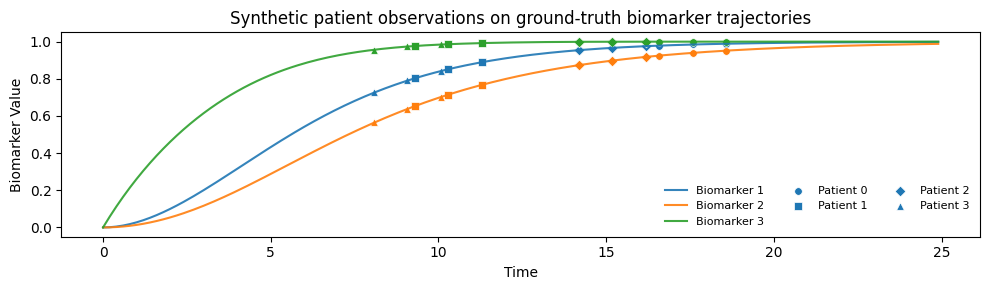

11.371801905439074
SUBTYPE 1:
f: [0.2 0.  0. ]
a = 1.1927249100009507, b = 6.8096301386771785


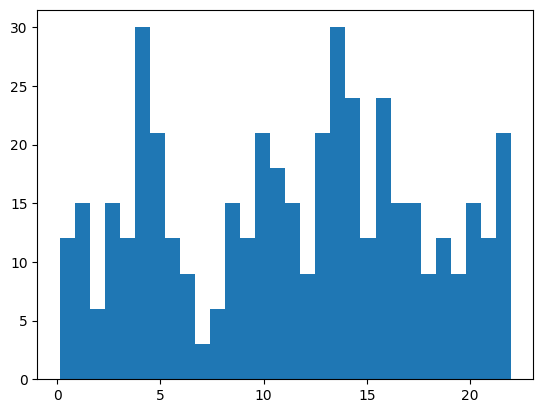

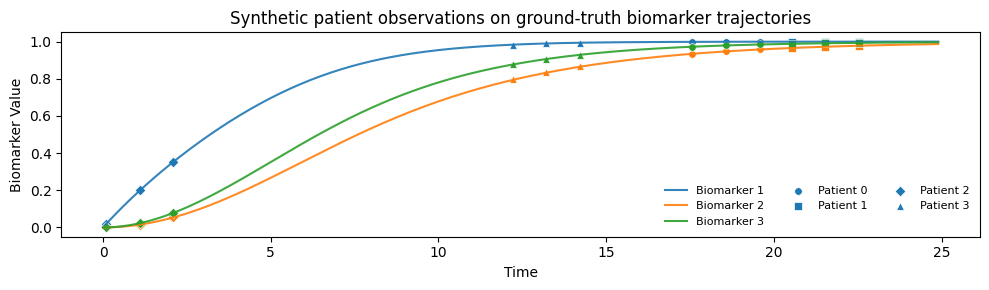

10.680411768908934


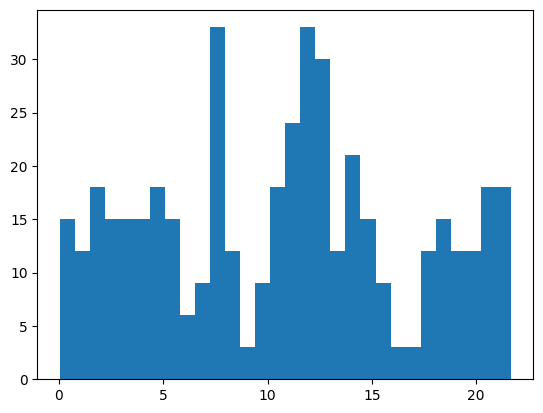

In [12]:
K = get_adjacency_matrix("random_offdiag", n_biomarkers, np.random.RandomState(75))

scalar_K_list = [0.2, 0.2]
f_list = []
for _ in range(n_subtypes):
    f_list.append(rng.gamma(shape=2, scale=0.005, size=n_biomarkers))

f_list = [np.array([0.0, 0.0, 0.3]), np.array([0.2, 0.0, 0.0])]

X = []
y = []

for subtype in range(n_subtypes):
    print(f"SUBTYPE {subtype}:")
    t, x_true, K, x0, f, scalar_K  = generate_logistic_model(n_biomarkers = n_biomarkers,
                                                             scalar_K = scalar_K_list[subtype],
                                                             t_max = t_max,
                                                             K = K,
                                                             f = f_list[subtype])

    print(f"f: {f}")
    
    df, cog_a, cog_b = generate_synthetic_data(
        n_biomarkers = n_biomarkers,
        t_max = t_max, 
        noise_level = noise_level,
        n_patients = n_patients,
        n_patient_obs = n_patient_obs,
        x_true=x_true, 
        t=t,
        rng = np.random.RandomState(75 + subtype + 2),
    )

    plot_true_observations(df, t, x_true, patient_idx=[0,1,2,3])

    biomarker_cols = [col for col in df.columns if col.startswith("biomarker_")]

    X_obs = df[biomarker_cols].values   # (n_obs, n_biomarkers)
    dt = df["dt"].values                # (n_obs,)
    ids = df["patient_id"].values + subtype * n_patients # (n_obs,),  `+ subtype * n_patients` is for ensuring all ids are unique
    cog = df["cognitive_score"].values  # (n_obs,)
    beta_true = df["beta_true"].values  # (n_obs)
    
    plt.hist(beta_true, bins=30)
    print(np.mean(beta_true))
    
    X_subtype = create_patient_list(X_obs, ids, dt, cog, initial_beta=None)
    
    for p in X_subtype: # tag each patient with true subtype for later eval
        p["subtype_true"] = int(subtype)
    X += X_subtype # pythonic concatenate list syntactic sugar
    
    y.append(beta_true[::n_patient_obs] )
    
X = np.asarray(X)
y = np.concatenate(y)


In [13]:
all_dt = np.concatenate([p["dt"] for p in X])
all_cog = np.concatenate([p["cog"] for p in X])
all_ids_array = np.concatenate([[p["id"]] * len(p["dt"]) for p in X])

initial_beta, pid_to_beta, result = fit_mixedlm_beta_from_clinical(
    ids=all_ids_array,
    dt=all_dt,
    cog=all_cog,
    t_max=t_max,
    verbose=True,
    rng=np.random.default_rng(75)
)

unique_ids = np.unique([p["id"] for p in X])
beta_true_array = y
        
print(f"Initialized beta for {len(initial_beta)} patients")
print(f"Beta range: [{np.min(initial_beta):.2f}, {np.max(initial_beta):.2f}]")
print(f"True beta range: [{np.min(beta_true_array):.2f}, {np.max(beta_true_array):.2f}]")


β_init summary: count    300.000000
mean      10.788830
std        8.559708
min        0.000000
25%        4.011096
50%        7.336175
75%       19.590477
max       25.000000
dtype: float64
Initialized beta for 300 patients
Beta range: [0.00, 25.00]
True beta range: [0.05, 21.97]


## Grid Search with K-Fold Cross-Validation

We'll perform grid search over hyperparameters using K-fold cross-validation (not group k-fold).


In [14]:
# Initialize f for all models
f_init = initialize_f_eigen(K=K)
if isinstance(f_init, list):
    f_init = f_init[0]

# Add initial_beta to patient data
unique_ids = np.unique([p["id"] for p in X])
id_to_beta_idx = {pid: idx for idx, pid in enumerate(unique_ids)}
for p in X:
    p["initial_beta"] = initial_beta[id_to_beta_idx[p["id"]]]


In [15]:
# Define parameter grid for grid search
param_grid = {
    "lambda_f": [0.3, 0.5, 0.7],
    "lambda_cog": [0.0],
    "lambda_scalar": [0.05, 0.1, 0.2],
    "lambda_jsd": [0.01, 1.0, 10, 100],
    "epsilon": [1e-2],
    "jac_toggle": [True],
    "max_iter": [1000],
    "t_max": [t_max],
    "step": [0.01],
    "n_subtypes": [n_subtypes],
    "initial_f": [f_init],
    "K": [K],
    "verbose": [0],  # Set to 0 to reduce output during grid search
    "rng": [np.random.default_rng(75)],
}

print(f"Parameter grid size: {np.prod([len(v) for v in param_grid.values()])} combinations")
print(f"K-fold CV will be performed for each combination")


Parameter grid size: 36 combinations
K-fold CV will be performed for each combination


In [ ]:
# Set up K-fold cross-validation (not GroupKFold)
n_splits = 3
kf = KFold(n_splits=n_splits, shuffle=True, random_state=75)

# Create base estimator
base_estimator = SubtypingEM(
    K=K,
    initial_f=f_init,
    n_subtypes=n_subtypes,
    jac_toggle=True,
    max_iter=1000,
    t_max=t_max,
    step=0.01,
    epsilon=5e-2,
    lambda_f=0.5,
    lambda_cog=0.001,
    lambda_scalar=0.1,
    lambda_jsd=0.1,
    verbose=1,
    rng=np.random.default_rng(75)
)

# Perform grid search with K-fold CV
print(f"Starting grid search with {n_splits}-fold cross-validation...")

grid = GridSearchCV(
    estimator=base_estimator,
    param_grid=param_grid,
    cv=kf,
    scoring=None,
    n_jobs=-1, 
    verbose=1,
    return_train_score=False
)

# Fit grid search
grid.fit(X=X, y=None)

print("\nGrid search completed!")
print(f"Best score: {grid.best_score_:.6f}")
print(f"Best parameters: {grid.best_params_}")


Starting grid search with 3-fold cross-validation...
Fitting 3 folds for each of 36 candidates, totalling 108 fits


Estimating beta values: 100%|██████████| 100/100 [00:00<00:00, 294.17it/s]


## Evaluate Best Model

Now we'll evaluate the best model found by grid search on the full dataset.


In [ ]:
# Get the best model
best_model = grid.best_estimator_

# Fit on full dataset with best parameters
best_model.verbose = 1  # Enable verbose output for final fit
best_model.fit(X)

print(f"\nBest model final LSE: {best_model.lse_history[-1]:.6f}")


AttributeError: 'SubtypingEM' object has no attribute 'jsd_value_range'

In [ ]:
# Compute subtype mapping
best_model.compute_subtype_mapping(f_list, verbose=True)
subtype_mapping = best_model.subtype_mapping

# Print parameter comparison
print_parameter_comparison(
    fitted_f_list=best_model.cluster_f,
    fitted_scalar_K_list=best_model.cluster_scalar_K,
    fitted_s=best_model.final_s,
    true_f_list=f_list,
    true_scalar_K_list=scalar_K_list,
    true_s=np.ones(n_biomarkers),
    subtype_mapping=best_model.subtype_mapping,
    n_subtypes=n_subtypes,
)

# Confusion matrix
assignments_true = np.array([p["subtype_true"] for p in X])
mapped_assignments = subtype_mapping[best_model.final_assignments]
print("\n=== Confusion Matrix: Best Model (with mapping) ===")
cm_best = confusion_matrix(assignments_true, mapped_assignments)
print(cm_best)

# Adjusted Rand Index
ari = adjusted_rand_score(assignments_true, mapped_assignments)
print(f"\nAdjusted Rand Index: {ari:.4f}")


## Visualizations


In [ ]:
# Plot LSE history
plot_lse(best_model.lse_history)
plt.title("LSE History: Best Model from Grid Search")
plt.show()


In [ ]:
# Plot beta history by subtype
plot_beta_history_by_subtype(
    beta_history=best_model.beta_history,
    assignments=best_model.final_assignments,
    n_subtypes=n_subtypes,
    beta_true=beta_true_array,
    subtype_mapping=subtype_mapping,
)


In [ ]:
# Plot true vs predicted subtype trajectories
plot_true_vs_predicted_subtype_trajectories(
    n_subtypes=n_subtypes,
    f_true_list=f_list,
    scalar_K_true_list=scalar_K_list,
    f_pred_list=best_model.cluster_f,
    scalar_K_pred_list=best_model.cluster_scalar_K,
    K=K,
    t_span=t_span,
    n_biomarkers=n_biomarkers,
    solve_system_fn=solve_system,
    subtype_mapping=subtype_mapping,
)


In [ ]:
# Plot assignment accuracy over iterations
plot_assignment_accuracy_history(
    assignment_history=best_model.assignment_history,
    true_assignments=assignments_true,
    subtype_mapping=subtype_mapping,
    title="Best Model: Assignment Accuracy Over Iterations",
)


In [ ]:
# Plot beta comparison
beta_init_array = np.array([p.get("initial_beta", np.nan) for p in X])
if np.any(np.isnan(beta_init_array)):
    beta_init_array = initial_beta

beta_final_array = best_model.beta_history[:, -1]
plot_beta_comparison(beta_true_array, beta_init_array, beta_final_array)


## Grid Search Results Summary


In [ ]:
# Display grid search results
results_df = pd.DataFrame(grid.cv_results_)
print("Top 5 parameter combinations:")
print(results_df[["mean_test_score", "std_test_score", "params"]].nlargest(5, "mean_test_score"))

# Plot scores distribution
plt.figure(figsize=(10, 6))
plt.hist(results_df["mean_test_score"], bins=20, edgecolor="black")
plt.axvline(grid.best_score_, color="red", linestyle="--", linewidth=2, label=f"Best score: {grid.best_score_:.4f}")
plt.xlabel("Mean CV Score")
plt.ylabel("Frequency")
plt.title("Distribution of Cross-Validation Scores")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
